# California Housing Price Prediction — OLS from Scratch

**Author:** Elaheh Lotfian (PhD Statistics)  
**Date:** 10 July 2026

## Project overview
This notebook implements Ordinary Least Squares regression
from scratch using NumPy, validates it against scikit-learn,
and evaluates the model on the California Housing dataset.

## Skills demonstrated
- NumPy linear algebra (normal equations)
- Exploratory data analysis
- Feature engineering (log transformation)
- Model evaluation (RMSE, MAE, R²)
- Residual diagnostics

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 

plt.style.use('seaborn-v0_8')
print("Setup complete")

Setup complete


## 1. Exploratory Data Analysis

Load the dataset and examine its structure, distributions,
and relationships before modeling.

In [34]:
data = fetch_california_housing(as_frame=True)
df = data.frame  
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head() 

Shape: (20640, 9)

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [35]:
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

             MedInc      HouseAge  ...     Longitude   MedHouseVal
count  20640.000000  20640.000000  ...  20640.000000  20640.000000
mean       3.870671     28.639486  ...   -119.569704      2.068558
std        1.899822     12.585558  ...      2.003532      1.153956
min        0.499900      1.000000  ...   -124.350000      0.149990
25%        2.563400     18.000000  ...   -121.800000      1.196000
50%        3.534800     29.000000  ...   -118.490000      1.797000
75%        4.743250     37.000000  ...   -118.010000      2.647250
max       15.000100     52.000000  ...   -114.310000      5.000010

[8 rows x 9 columns]

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## 2. Target Distribution

Checking whether the target variable is skewed, and whether a log transform 
produces a more symmetric distribution. This matters because OLS assumes 
normally distributed residuals.

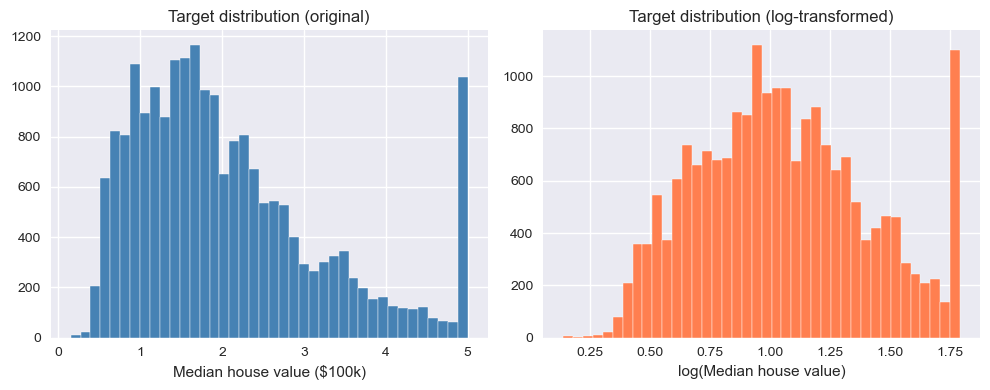

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df['MedHouseVal'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title("Target distribution (original)")
axes[0].set_xlabel("Median house value ($100k)")

axes[1].hist(np.log1p(df['MedHouseVal']), bins=40,
             color='coral', edgecolor='white')
axes[1].set_title("Target distribution (log-transformed)")
axes[1].set_xlabel("log(Median house value)")

plt.tight_layout()
plt.show()

## 3. Feature Correlations

Examining pairwise correlations to identify multicollinearity risks and which 
features are most linearly associated with the target.

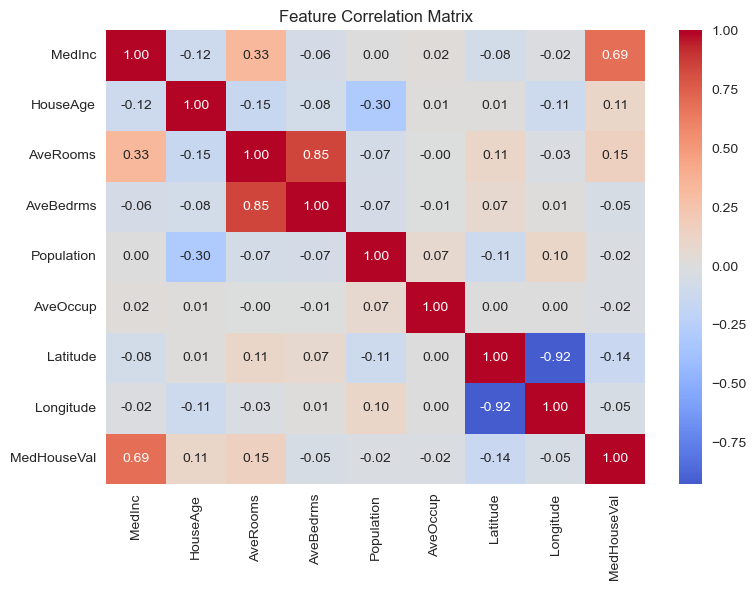

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. OLS Implementation from Scratch

Implementing OLS manually using the normal equation via `np.linalg.lstsq` 
(avoids direct matrix inversion), then splitting into train/test sets.


In [38]:
X = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]

beta, _, _, _ = np.linalg.lstsq(X_train_b, y_train, rcond=None)
y_pred = X_test_b @ beta

## 5. Validation Against scikit-learn

Confirming the manual OLS implementation matches scikit-learn's `LinearRegression`. 
This validates the from-scratch math is correct.

In [39]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_sklearn = lr.predict(X_test)

print("Manual beta (first 3):", beta[:3])
print("Sklearn intercept + first 2 coefs:", lr.intercept_, lr.coef_[:2])

Manual beta (first 3): [-3.70232777e+01  4.48674910e-01  9.72425752e-03]
Sklearn intercept + first 2 coefs: -37.02327770606397 [0.44867491 0.00972426]


## 6. Model Evaluation

Evaluating predictive performance using RMSE, MAE, and R².

In [40]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:4f}")
print(f"MAE: {mae:4f}")
print(f"R2: {r2:4f}")

RMSE: 0.745581
MAE: 0.533200
R2: 0.575788


## 7. Residual Diagnostics

Checking whether OLS assumptions hold. Residuals should be randomly scattered 
around zero with no clear pattern (homoscedasticity), and approximately normally 
distributed.

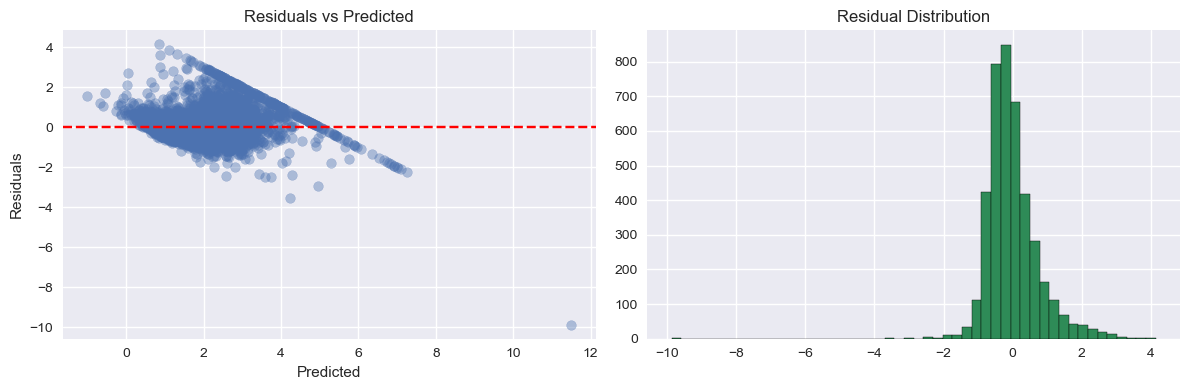

In [41]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 8. Conclusion & Business Interpretation

The model explains about 58% of the differences in house values, with an R² score of 0.576. On average, its predictions are off by about $\$74{,}600$ based on RMSE, while the typical error is around $\$53{,}300$ based on MAE.

Since house prices in this dataset can be higher than $\$500{,}000$, this is a reasonable starting point. However, the model is not accurate enough to estimate the price of a specific house. It is better at showing general patterns in the housing market.

Median income is the most important factor related to house value, with a correlation of 0.69. This is expected because homes in wealthier areas are usually more expensive. Average number of rooms also has a positive relationship with house value, but it is much weaker, with a correlation of 0.15.

I did not compare the raw model coefficients because the features use different scales and were not standardized. Comparing them directly could therefore be misleading.

The correlation matrix also shows two cases of strong correlation between features. AveRooms and AveBedrms have a correlation of 0.85, while Latitude and Longitude have a correlation of -0.92. The second case is mainly due to California’s geography. These strong relationships can make it harder for the model to clearly separate the effect of each feature.

The residual plot shows two important issues. First, house values above $\$500{,}000$ were capped at 5.00001 in the dataset. This creates the straight diagonal pattern in the residual plot. For these houses, the error is partly caused by the artificial price cap, not only by the model.

Second, some predictions are as high as $\$1.2$ million, even though values in the dataset are capped at around $\$500{,}000$. This may be caused by extreme values in features such as AveRooms or AveOccup, which can strongly affect a linear regression model.

To improve the results, I would first remove or separately study the capped rows. I would also check and transform extreme outliers. After that, I would try a tree-based model such as Random Forest, which can handle non-linear patterns and outliers better than a basic linear regression model.
